### Extracting scFM attention weights with DECONVersation

This tutorial covers attention-based interpretability of single-cell foundation models in DECONVersation. It walks through extracting per-gene attention weights from Geneformer, Cell2Sentence, and Cell Hermes, using both the pretrained zero-shot models and their fine-tuned counterparts. The top attended genes for each cell type are then tested for cell type marker enrichment by over-representation analysis, and the enrichment results are compared between the fine-tuned and zero-shot models to reveal which biological programs the model learns during fine-tuning. The tutorial ends by visualizing the per-term differences in enrichment across cell types.

#### Load libraries

In [10]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import time
import gseapy as gp
import pandas as pd
import deconversation
deconversation.__file__
from deconversation import preprocessing, attention

In [3]:
import warnings
warnings.filterwarnings('ignore')

#### Load data

Here we load the single-cell PBMC dataset from Hao et al., limiting the cell
types to B cells, monocytes, NK cells, and T cells.

Gene identifiers must match what each model expects:

- **Geneformer** — set `adata.var.index` to Ensembl IDs, then prepare the object
  with `preprocessing.load_and_prep_data()` before extracting attention weights.
- **Cell Hermes and scGPT** — set `adata.var.index` to gene symbols.

In [5]:
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_id"]
#adata_ref.var.index = adata_ref.var["gene_name"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
adata_ref = preprocessing.load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="geneformer")

#### Functions to run cell type enrichment and visualize results

Here we define two functions.

`process_attention()` takes attention weights from both the zero-shot and
fine-tuned models. These weights are nested dictionaries: each key is a cell
type, and each value is a dictionary mapping genes to attention weights. Passing
both in combines the results into a single dataframe, then runs enrichment
analysis against the [PanglaoDB(2021)](https://pmc.ncbi.nlm.nih.gov/articles/PMC6450036/) cell type markers. Enriched categories are
compared by subtracting the zero-shot enrichment score from the fine-tuned score
for each shared category.

`plot_results()` plots the change in enrichment across those shared categories.
A positive delta means higher enrichment with the fine-tuned model, and a
negative delta means the reverse. 

We run cell type enrichment with `enrichr()` from the
[gseapy](https://pypi.org/project/gseapy/) package, which must be installed
separately. See the [documentation](https://gseapy.readthedocs.io/en/latest/introduction.html#installation) for
other installation options.

In [12]:
def _enrichr(genes, gene_set):
    try:
        res = gp.enrichr(gene_list=genes, gene_sets=gene_set, organism="human", no_plot=True)
        time.sleep(2)
        return res.results if res is not None else pd.DataFrame()
    except Exception as e:
        print(f"Enrichr failed: {e}")
        return pd.DataFrame()


def process_attention(
    attn_zs,
    attn_ft,
    gene_set="PanglaoDB_Augmented_2021",
    rank=2,
    n_genes=120,
):
    cell_types = sorted(attn_zs.keys() & attn_ft.keys())
    if not cell_types:
        raise ValueError("No matching cell types found in both attention dictionaries.")

    rows = []
    for cell_type in cell_types:
        df = pd.DataFrame({"zs": pd.Series(attn_zs[cell_type]), "ft": pd.Series(attn_ft[cell_type])})

        res_ft = _enrichr(df["ft"].nlargest(n_genes).index.astype(str).tolist(), gene_set)
        if res_ft.empty:
            continue
        res_zs = _enrichr(df["zs"].nlargest(n_genes).index.astype(str).tolist(), gene_set)

        zs_scores = (
            res_zs.drop_duplicates("Term").set_index("Term")["Combined Score"]
            if not res_zs.empty
            else pd.Series(dtype=float)
        )

        top_ft = res_ft.nsmallest(rank, "Adjusted P-value")
        for i, (term, cs_ft) in enumerate(zip(top_ft["Term"], top_ft["Combined Score"]), start=1):
            cs_zs = zs_scores.get(term, 0.0)
            delta = cs_ft - cs_zs
            rows.append({
                "cell_type": cell_type,
                "ft_rank": i,
                "Term": term,
                "cs_ft": cs_ft,
                "cs_zs": cs_zs,
                "delta_score": delta,
                "log_delta": np.sign(delta) * np.log10(abs(delta) + 1),
            })

    return pd.DataFrame(rows)


# Function to plot results
def plot_results(results):

    # Sort by cell_type first, then by delta_score within each group
    df = results.sort_values(["cell_type", "delta_score"], ascending=[True, True]).reset_index(drop=True)
    
    # Assign a color to each unique cell_type
    cell_types = df["cell_type"].astype(str).unique()
    palette = plt.get_cmap("tab10")
    color_map = {ct: palette(i) for i, ct in enumerate(cell_types)}
    
    # Use a list comprehension instead of .map() to avoid Categorical dtype issues
    colors = [color_map[ct] for ct in df["cell_type"].astype(str)]
    
    # One numeric position per row, so repeated terms get their own bar
    y_pos = np.arange(len(df))
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, max(4, len(df) * 0.35)))
    
    ax.barh(
        y=y_pos,
        width=df["delta_score"],
        color=colors,
        height=0.7,
        edgecolor="white",
        linewidth=0.5,
    )
    
    # Use the terms as tick labels only
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["Term"])
    ax.set_ylim(-0.5, len(df) - 0.5)
    
    # Legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map[ct], label=ct)
        for ct in cell_types
    ]
    ax.legend(handles=handles, title="Cell type", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    
    # Axes
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Delta Enrichment", fontsize=11)
    ax.set_ylabel("")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    
    plt.tight_layout()
    #plt.savefig("delta_score_by_term.png", dpi=150, bbox_inches="tight")
    plt.show()

#### Geneformer

Here we extract Geneformer attention weights directly from the single-cell
reference data, using `attention.get_attention()` with both the zero-shot model
(`ctheodoris/Geneformer`) and a fine-tuned model.

In [9]:
# Zeroshot
res_zs = attention.get_attention(
    data = adata_ref, 
    mode = "geneformer",
    model_path = "ctheodoris/Geneformer",
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/attention_tests/df/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'],
    output_name = "gf_attention",
    cell_type_col = "cell_type",
    model_version = "V2",
    num_of_cells = 50,
    random_state = 42,
    min_cells_per_cell_type = 200,
)

In [60]:
# Fine-tuned
res_ft = attention.get_attention(
    data = adata_ref, 
    mode = "geneformer",
    model_path = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/attention_tests/df/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'],
    output_name = "gf_attention",
    cell_type_col = "cell_type",
    model_version = "V2",
    num_of_cells = 50,
    random_state = 42,
    min_cells_per_cell_type = 200,
)

In [61]:
results_gf = process_attention(
    attn_zs=res_zs,
    attn_ft=res_ft,
    rank=4,
    n_genes=100,
)

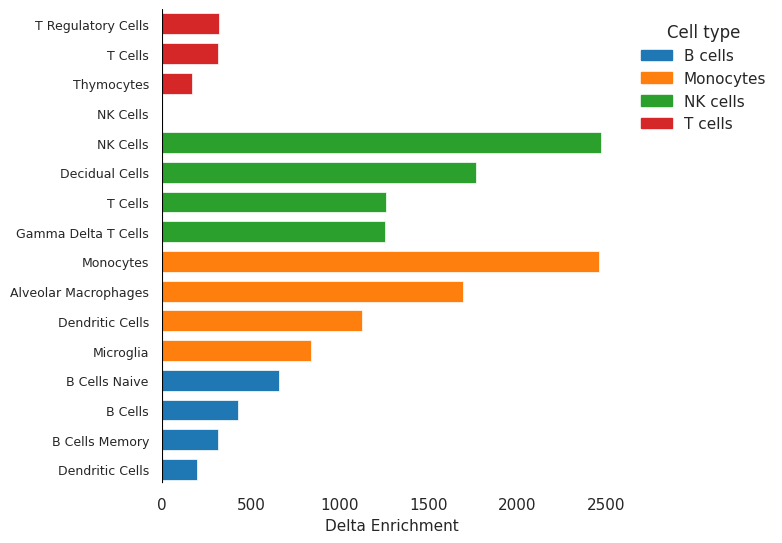

In [62]:
plot_results(results_gf)

#### Cell2Sentence

Here we extract attention weights from Cell2Sentence, using both the zero-shot
and fine-tuned models.

In [13]:
# Zero-shot
res_zs = attention.get_attention(
    data = adata_ref, 
    mode = "c2s",
    model_path = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Scale-Gemma-2-2B",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'], 
    cell_type_col="broad_type",
    num_of_cells=5, 
    random_state=42, 
    n_genes=150)

In [14]:
# Fine-tuned
res_ft = attention.get_attention(
    data = adata_ref, 
    mode = "c2s",
    model_path="/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/pbmc/c2s/2b/2026-02-02-13_12_05_finetune_cell_type_prediction/checkpoint-3800",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'], 
    cell_type_col="broad_type",
    num_of_cells=5, 
    random_state=42, 
    n_genes=150)

In [16]:
results_c2s = process_attention(
    attn_zs=res_zs,
    attn_ft=res_ft,
    rank=4,
    n_genes=100,
)

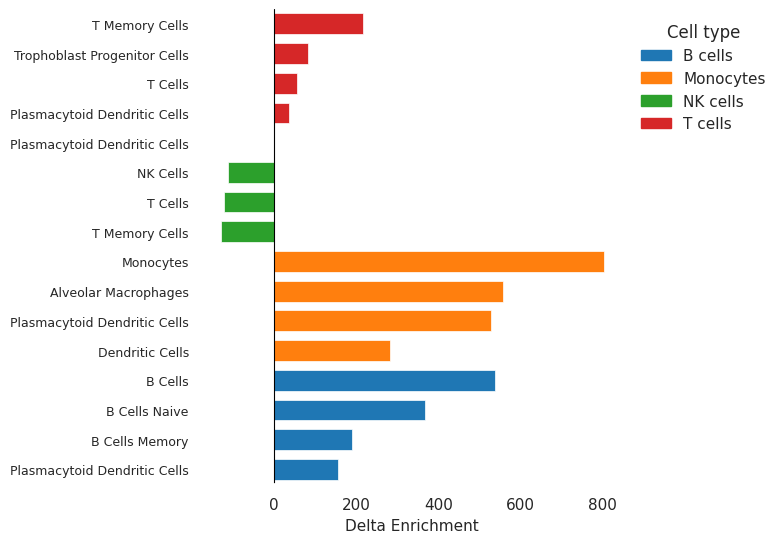

In [17]:
plot_results(results_c2s)

#### cellHermes

Here we extract attention weights from Cell Hermes, using both the zero-shot
and fine-tuned models.

In [21]:
# Zero-shot
res_zs = attention.get_attention(
    data = adata_ref, 
    mode = "cellhermes",
    model_path = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'], 
    cell_type_col="broad_type",
    num_of_cells=5, 
    random_state=42, 
    n_genes=150)

In [22]:
# Fine-tuned
res_ft = attention.get_attention(
    data = adata_ref, 
    mode = "c2s",
    model_path="/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes_ft_pbmc800rmmr200/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'], 
    cell_type_col="broad_type",
    num_of_cells=5, 
    random_state=42, 
    n_genes=150)

In [23]:
results_ch = process_attention(
    attn_zs=res_zs,
    attn_ft=res_ft,
    rank=4,
    n_genes=100,
)

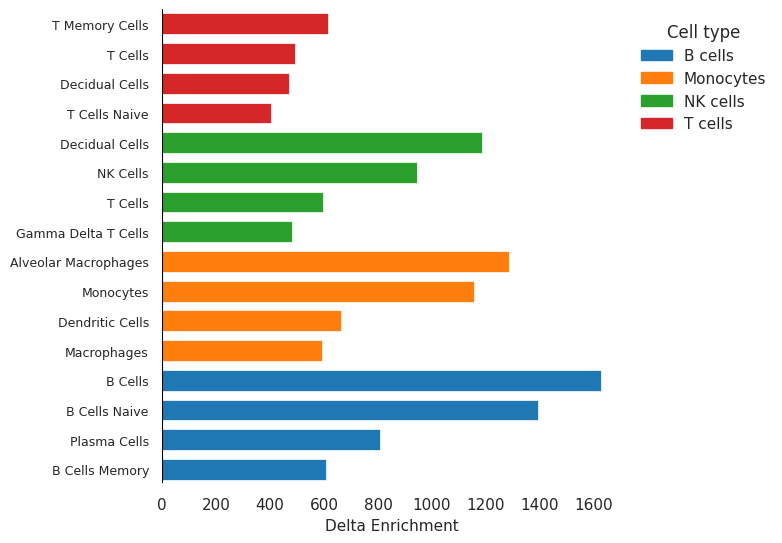

In [24]:
plot_results(results_ch)

#### Geneformer (directly from signature matrix)

Here we extract Geneformer attention weights from signature matrix data loaded
as a dataframe, where rows are the four cell types and columns are genes
(Ensembl IDs). `attention.get_attention()` accepts either single-cell AnnData or
a signature matrix, so we can repeat the same analysis as above on this input.

**Note:** When using the signature matrix, although the default `num_of_cells` in `attention.get_attention()` is 50, there is effectively **1 cell per cell type**, since expression values have been averaged across cell types to create the cell type signature matrix. Internally, `min(total_cells_per_celltype, num_of_cells)` is used, which resolves to 1 in this case.

In [2]:
pb_data = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/sig_mat_data_hao800.csv", index_col=0)

In [2]:
# zeroshot
sig_mat_zs = attention.get_attention(
    data = pb_data, 
    mode = "geneformer",
    model_path = "ctheodoris/Geneformer",
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/attention_tests/df/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'],
    output_name = "gf_attention",
    cell_type_col = "cell_type",
    model_version = "V2",
    random_state = 42,
)

In [33]:
# fine-tuned
sig_mat_ft = attention.get_attention(
    data = pb_data, 
    mode = "geneformer",
    model_path = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/attention_tests/df/",
    cell_types = ['B cells', 'Monocytes', 'NK cells', 'T cells'],
    output_name = "gf_attention",
    cell_type_col = "cell_type",
    model_version = "V2",
    random_state = 42,
)

In [34]:
results_sig_mat_gf = process_attention(
    attn_zs=sig_mat_zs,
    attn_ft=sig_mat_ft,
    rank=4,
    n_genes=100)

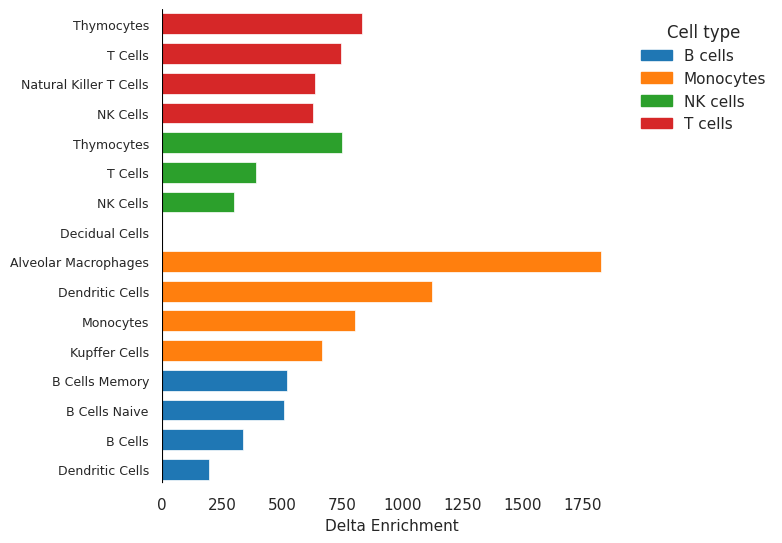

In [35]:
plot_results(results_sig_mat_gf)